In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from arch import arch_model

In [2]:
ret = pd.read_csv("../data/processed/dax_log_returns.csv", 
                  index_col=0, 
                  parse_dates=True)

ret = ret.squeeze()  # تبدیل به Series
ret.head()

Date
2014-01-03    0.372817
2014-01-06   -0.075813
2014-01-07    0.826025
2014-01-08   -0.087985
2014-01-09   -0.805836
Name: ^GDAXI, dtype: float64

In [3]:
n = len(ret)
n_test = int(0.2 * n)

ret_train = ret.iloc[:-n_test]
ret_test = ret.iloc[-n_test:]

print("Train size:", len(ret_train))
print("Test size:", len(ret_test))

Train size: 2460
Test size: 614


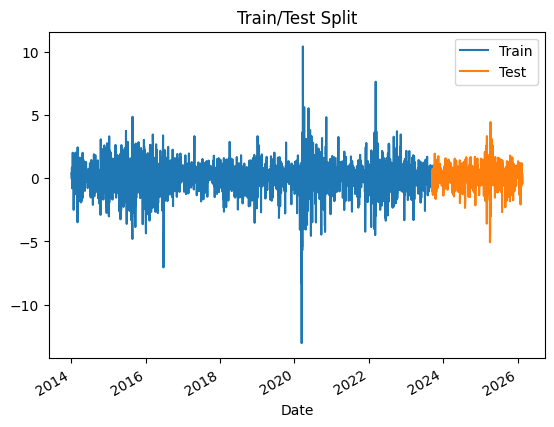

In [4]:
plt.figure()
ret_train.plot(label="Train")
ret_test.plot(label="Test")
plt.legend()
plt.title("Train/Test Split")
plt.show()

In [5]:
from arch import arch_model

am = arch_model(ret_train, mean="Zero", vol="GARCH", p=1, q=1, dist="normal")
res = am.fit(disp="off")
print(res.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                 ^GDAXI   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3716.76
Distribution:                  Normal   AIC:                           7439.52
Method:            Maximum Likelihood   BIC:                           7456.95
                                        No. Observations:                 2460
Date:                Tue, Feb 17 2026   Df Residuals:                     2460
Time:                        19:23:16   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0517  1.857e-02      2.787  5.322e-03 [1.

In [6]:
window = 1500  # حدوداً ~6 سال کاری؛ اگر ارور داد می‌گیم کمترش کن

sigma_forecasts = []
dates = []

for i in range(len(ret_test)):
    start = max(0, len(ret_train) - window + i)
    end = len(ret_train) + i
    train_slice = ret.iloc[start:end]

    model = arch_model(train_slice, mean="Zero", vol="GARCH", p=1, q=1, dist="normal")
    fit = model.fit(disp="off")

    fcast = fit.forecast(horizon=1, reindex=False)
    sigma2 = fcast.variance.values[-1, 0]  # variance forecast
    
    sigma_forecasts.append(np.sqrt(sigma2))  # sigma
    dates.append(ret_test.index[i])

sigma_forecasts = pd.Series(sigma_forecasts, index=dates, name="sigma_garch11")
sigma_forecasts.head()

2023-09-15    0.801149
2023-09-18    0.800869
2023-09-19    0.865189
2023-09-20    0.841484
2023-09-21    0.853091
Name: sigma_garch11, dtype: float64

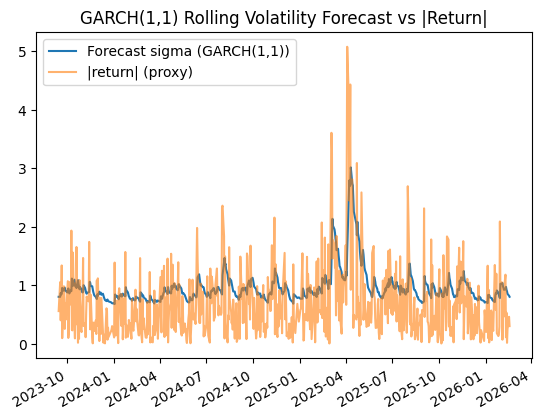

In [7]:
plt.figure()
sigma_forecasts.plot(label="Forecast sigma (GARCH(1,1))")
np.abs(ret_test).reindex(sigma_forecasts.index).plot(label="|return| (proxy)", alpha=0.6)
plt.legend()
plt.title("GARCH(1,1) Rolling Volatility Forecast vs |Return|")
plt.show()

In [8]:
sigma_forecasts.to_csv("../results/tables/garch11_sigma_forecasts.csv")
print("Saved: results/tables/garch11_sigma_forecasts.csv")

Saved: results/tables/garch11_sigma_forecasts.csv


In [9]:
models = {}

# GARCH(1,1)
garch = arch_model(ret_train, mean="Zero", vol="GARCH", p=1, q=1, dist="normal")
res_garch = garch.fit(disp="off")
models["GARCH(1,1)"] = res_garch

# EGARCH(1,1)
egarch = arch_model(ret_train, mean="Zero", vol="EGARCH", p=1, q=1, dist="normal")
res_egarch = egarch.fit(disp="off")
models["EGARCH(1,1)"] = res_egarch

# GJR-GARCH(1,1)
gjr = arch_model(ret_train, mean="Zero", vol="GARCH", p=1, o=1, q=1, dist="normal")
res_gjr = gjr.fit(disp="off")
models["GJR-GARCH(1,1)"] = res_gjr

print("Models fitted successfully.")

Models fitted successfully.


In [10]:
comparison = pd.DataFrame({
    "AIC": {name: model.aic for name, model in models.items()},
    "BIC": {name: model.bic for name, model in models.items()}
})

comparison.sort_values("AIC")

,AIC,BIC
"GJR-GARCH(1,1)",7355.460025,7378.691691
"GARCH(1,1)",7439.521589,7456.945338
"EGARCH(1,1)",7456.229236,7473.652986


In [11]:
window = 1500

sigma_gjr = []
dates = []

for i in range(len(ret_test)):
    start = max(0, len(ret_train) - window + i)
    end = len(ret_train) + i
    train_slice = ret.iloc[start:end]

    model = arch_model(train_slice, mean="Zero", vol="GARCH",
                       p=1, o=1, q=1, dist="normal")
    
    fit = model.fit(disp="off")
    fcast = fit.forecast(horizon=1, reindex=False)
    
    sigma2 = fcast.variance.values[-1, 0]
    sigma_gjr.append(np.sqrt(sigma2))
    dates.append(ret_test.index[i])

sigma_gjr = pd.Series(sigma_gjr, index=dates, name="sigma_gjr")
sigma_gjr.head()

2023-09-15    0.769048
2023-09-18    0.755153
2023-09-19    0.902829
2023-09-20    0.886071
2023-09-21    0.854952
Name: sigma_gjr, dtype: float64

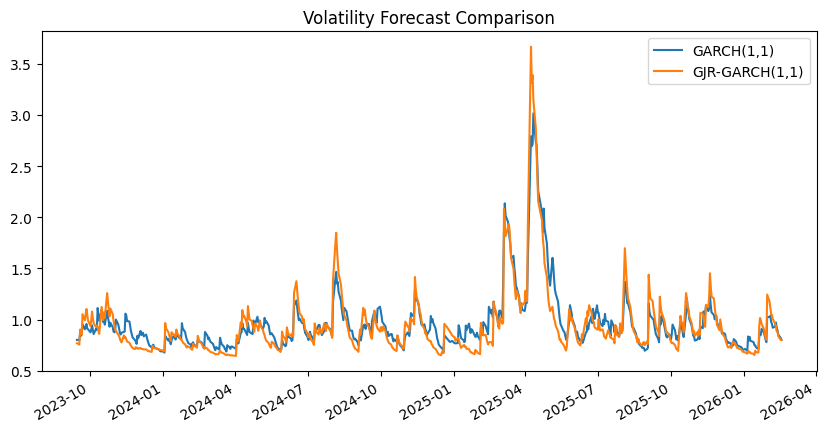

In [12]:
plt.figure(figsize=(10,5))

sigma_forecasts.plot(label="GARCH(1,1)")
sigma_gjr.plot(label="GJR-GARCH(1,1)")

plt.legend()
plt.title("Volatility Forecast Comparison")
plt.show()

In [13]:
sigma_gjr.to_csv("../results/tables/gjr_sigma_forecasts.csv")
print("Saved: results/tables/gjr_sigma_forecasts.csv")

Saved: results/tables/gjr_sigma_forecasts.csv


In [14]:
ret_test_aligned = ret_test.reindex(sigma_forecasts.index)
true_var = (ret_test_aligned ** 2)  # proxy for variance
true_var.name = "true_var_proxy"
true_var.head()

2023-09-15    0.309963
2023-09-18    1.107863
2023-09-19    0.159270
2023-09-20    0.554772
2023-09-21    1.789869
Name: true_var_proxy, dtype: float64

In [15]:
var_garch = sigma_forecasts**2
var_gjr = sigma_gjr**2

In [16]:
import numpy as np

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.sqrt(np.mean((y_true - y_pred)**2))

def qlike(y_true_var, y_pred_var):
    eps = 1e-12
    y_true_var = np.asarray(y_true_var)
    y_pred_var = np.maximum(np.asarray(y_pred_var), eps)
    return np.mean(np.log(y_pred_var) + (y_true_var / y_pred_var))

results_eval = pd.DataFrame({
    "RMSE (var)": {
        "GARCH(1,1)": rmse(true_var, var_garch),
        "GJR-GARCH(1,1)": rmse(true_var, var_gjr),
    },
    "QLIKE": {
        "GARCH(1,1)": qlike(true_var, var_garch),
        "GJR-GARCH(1,1)": qlike(true_var, var_gjr),
    }
})

results_eval

,RMSE (var),QLIKE
"GARCH(1,1)",1.780762,0.673768
"GJR-GARCH(1,1)",1.695234,0.650495


In [17]:
results_eval.to_csv("../results/tables/vol_forecast_evaluation.csv")
print("Saved: results/tables/vol_forecast_evaluation.csv")

Saved: results/tables/vol_forecast_evaluation.csv
